In [1]:
import pandas as pd
import os
from tqdm import tqdm

In [2]:
df_no_diagnosis = pd.read_csv('/data/moon/kiat/demographic_info.txt', \
            names=['Patient Num', 'Age', 'Sex', 'Adult BMI', 'Child Weight', 'Child Height'],\
            delimiter=' ')

diagnosis = pd.read_csv('/data/moon/kiat/respiratory_sound_database/Respiratory_Sound_Database/patient_diagnosis.csv', \
            names = ['Patient Num', 'Diagnosis'])

In [3]:
df = df_no_diagnosis.join(diagnosis.set_index('Patient Num'), on = 'Patient Num', how = 'left')
df['Diagnosis'].value_counts()

Diagnosis
COPD              64
Healthy           26
URTI              14
Bronchiectasis     7
Pneumonia          6
Bronchiolitis      6
LRTI               2
Asthma             1
Name: count, dtype: int64

In [4]:
def Extract_Annotation_Data(file_name, root):
    tokens = file_name.split('_')
    recording_info = pd.DataFrame(data = [tokens], columns = ['Patient number', 'Recording index', 'Chest location','Acquisition mode','Recording equipment'])
    recording_annotations = pd.read_csv(os.path.join(root, file_name + '.txt'), names = ['Start', 'End', 'Crackles', 'Wheezes'], delimiter= '\t')
    return (recording_info, recording_annotations)

In [5]:
root = '/data/moon/kiat/respiratory_sound_database/Respiratory_Sound_Database/audio_and_txt_files/'
filenames = [s.split('.')[0] for s in os.listdir(path = root) if '.txt' in s]
len(filenames)

920

In [6]:
i_list = []
rec_annotations = []
rec_annotations_dict = {}
for s in filenames:
    (i,a) = Extract_Annotation_Data(s, root)
    i_list.append(i)
    rec_annotations.append(a)
    rec_annotations_dict[s] = a
recording_info = pd.concat(i_list, axis = 0)
recording_info.sort_values('Patient number')

,Patient number,Recording index,Chest location,Acquisition mode,Recording equipment
0,101,1b1,Al,sc,Meditron
0,101,1b1,Pr,sc,Meditron
0,102,1b1,Ar,sc,Meditron
0,103,2b2,Ar,mc,LittC2SE
0,104,1b1,Lr,sc,Litt3200
...,...,...,...,...,...
0,224,1b1,Tc,sc,Meditron
0,225,1b1,Pl,sc,Meditron
0,226,1b1,Pl,sc,LittC2SE
0,226,1b1,Al,sc,Meditron


In [7]:
no_label_list = []
crack_list = []
wheeze_list = []
both_sym_list = []
filename_list = []
for f in filenames:
    d = rec_annotations_dict[f]
    no_labels = len(d[(d['Crackles'] == 0) & (d['Wheezes'] == 0)].index)
    n_crackles = len(d[(d['Crackles'] == 1) & (d['Wheezes'] == 0)].index)
    n_wheezes = len(d[(d['Crackles'] == 0) & (d['Wheezes'] == 1)].index)
    both_sym = len(d[(d['Crackles'] == 1) & (d['Wheezes'] == 1)].index)
    no_label_list.append(no_labels)
    crack_list.append(n_crackles)
    wheeze_list.append(n_wheezes)
    both_sym_list.append(both_sym)
    filename_list.append(f)

In [8]:
file_label_df = pd.DataFrame(data = {'filename':filename_list})
file_label_df

,filename
0,172_1b4_Al_mc_AKGC417L
1,193_1b2_Tc_mc_AKGC417L
2,170_1b4_Pr_mc_AKGC417L
3,205_2b3_Ar_mc_AKGC417L
4,200_2p3_Pl_mc_AKGC417L
...,...
915,163_2b2_Al_mc_AKGC417L
916,195_1b1_Al_sc_Litt3200
917,151_3p2_Pl_mc_AKGC417L
918,130_1p4_Ar_mc_AKGC417L


In [9]:
audio_path = '/data/moon/kiat/respiratory_sound_database/Respiratory_Sound_Database/audio_and_txt_files/'

In [10]:
# adding columns in file_label_df
diagnosis = []
patient_number = []
recording_index = []
chest_location = []
acquisition_mode = []
recording_equipment = []
sample_rate = []
duration = []

for i in tqdm(range(len(file_label_df['filename']))):
  info = file_label_df['filename'][i].split('_')
  patient_id, recording_idx, chest_loc, acq_mode, equipment = info
  #sound_filename = audio_path + file_label_df['filename'][i] + '.wav'
  #x, sr = librosa.load(sound_filename)
  #dur = round(x.shape[0]/sr, 2)
  #sample_rate.append(sr)
  #duration.append(dur)

  diagnosis.append(df['Diagnosis'][int(patient_id) - 101])
  patient_number.append(patient_id)
  recording_index.append(recording_idx)
  chest_location.append(chest_loc)
  acquisition_mode.append(acq_mode)
  recording_equipment.append(equipment)

file_label_df['Diagnosis'] = diagnosis
file_label_df['Patient Number'] = patient_number
file_label_df['Chest Location'] = chest_location
file_label_df['Acquisition Mode'] = acquisition_mode
file_label_df['Recording Equipment'] = recording_equipment
#file_label_df['duration'] = duration
#file_label_df['sample rate'] = sample_rate

100%|██████████| 920/920 [00:00<00:00, 111238.71it/s]


In [11]:
diagnosis_3 = []
for i in range(len(file_label_df['Diagnosis'])):
  diagnosis = file_label_df['Diagnosis'][i]
  if diagnosis == 'COPD' or diagnosis == 'Bronchiectasis' or diagnosis == 'Asthma':
    diagnosis_3.append('Chronic Disease')
  elif diagnosis == 'URTI' or diagnosis == 'LRTI' or diagnosis == 'Pneumonia' or diagnosis == 'Bronchiolitis':
    diagnosis_3.append('Non-Chronic Disease')
  else:
    diagnosis_3.append('normal')

file_label_df['3 label diagnosis'] = diagnosis_3

In [12]:
file_label_df.sort_values('Patient Number')

,filename,Diagnosis,Patient Number,Chest Location,Acquisition Mode,Recording Equipment,3 label diagnosis
538,101_1b1_Al_sc_Meditron,URTI,101,Al,sc,Meditron,Non-Chronic Disease
564,101_1b1_Pr_sc_Meditron,URTI,101,Pr,sc,Meditron,Non-Chronic Disease
294,102_1b1_Ar_sc_Meditron,Healthy,102,Ar,sc,Meditron,normal
533,103_2b2_Ar_mc_LittC2SE,Asthma,103,Ar,mc,LittC2SE,Chronic Disease
647,104_1b1_Lr_sc_Litt3200,COPD,104,Lr,sc,Litt3200,Chronic Disease
...,...,...,...,...,...,...,...
483,224_1b1_Tc_sc_Meditron,Healthy,224,Tc,sc,Meditron,normal
601,225_1b1_Pl_sc_Meditron,Healthy,225,Pl,sc,Meditron,normal
323,226_1b1_Pl_sc_LittC2SE,Pneumonia,226,Pl,sc,LittC2SE,Non-Chronic Disease
786,226_1b1_Al_sc_Meditron,Pneumonia,226,Al,sc,Meditron,Non-Chronic Disease


In [13]:
file_label_df['Diagnosis'].value_counts()

Diagnosis
COPD              793
Pneumonia          37
Healthy            35
URTI               23
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64

In [ ]:
# file_label_df.to_csv('file_label_df.csv')

In [93]:
pd.read_csv('file_label_df.csv')

,Unnamed: 0,filename,Diagnosis,Patient Number,Chest Location,Acquisition Mode,Recording Equipment,3 label diagnosis
0,0,172_1b4_Al_mc_AKGC417L,COPD,172,Al,mc,AKGC417L,Chronic Disease
1,1,193_1b2_Tc_mc_AKGC417L,COPD,193,Tc,mc,AKGC417L,Chronic Disease
2,2,170_1b4_Pr_mc_AKGC417L,COPD,170,Pr,mc,AKGC417L,Chronic Disease
3,3,205_2b3_Ar_mc_AKGC417L,COPD,205,Ar,mc,AKGC417L,Chronic Disease
4,4,200_2p3_Pl_mc_AKGC417L,COPD,200,Pl,mc,AKGC417L,Chronic Disease
...,...,...,...,...,...,...,...,...
915,915,163_2b2_Al_mc_AKGC417L,COPD,163,Al,mc,AKGC417L,Chronic Disease
916,916,195_1b1_Al_sc_Litt3200,COPD,195,Al,sc,Litt3200,Chronic Disease
917,917,151_3p2_Pl_mc_AKGC417L,COPD,151,Pl,mc,AKGC417L,Chronic Disease
918,918,130_1p4_Ar_mc_AKGC417L,COPD,130,Ar,mc,AKGC417L,Chronic Disease


In [14]:
# Audio file preprocessing

In [15]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

In [16]:
sound_filename = audio_path + file_label_df['filename'][100] + '.wav'

In [100]:
sound_filename

'/data/moon/kiat/respiratory_sound_database/Respiratory_Sound_Database/audio_and_txt_files/167_1b1_Pr_sc_Meditron.wav'

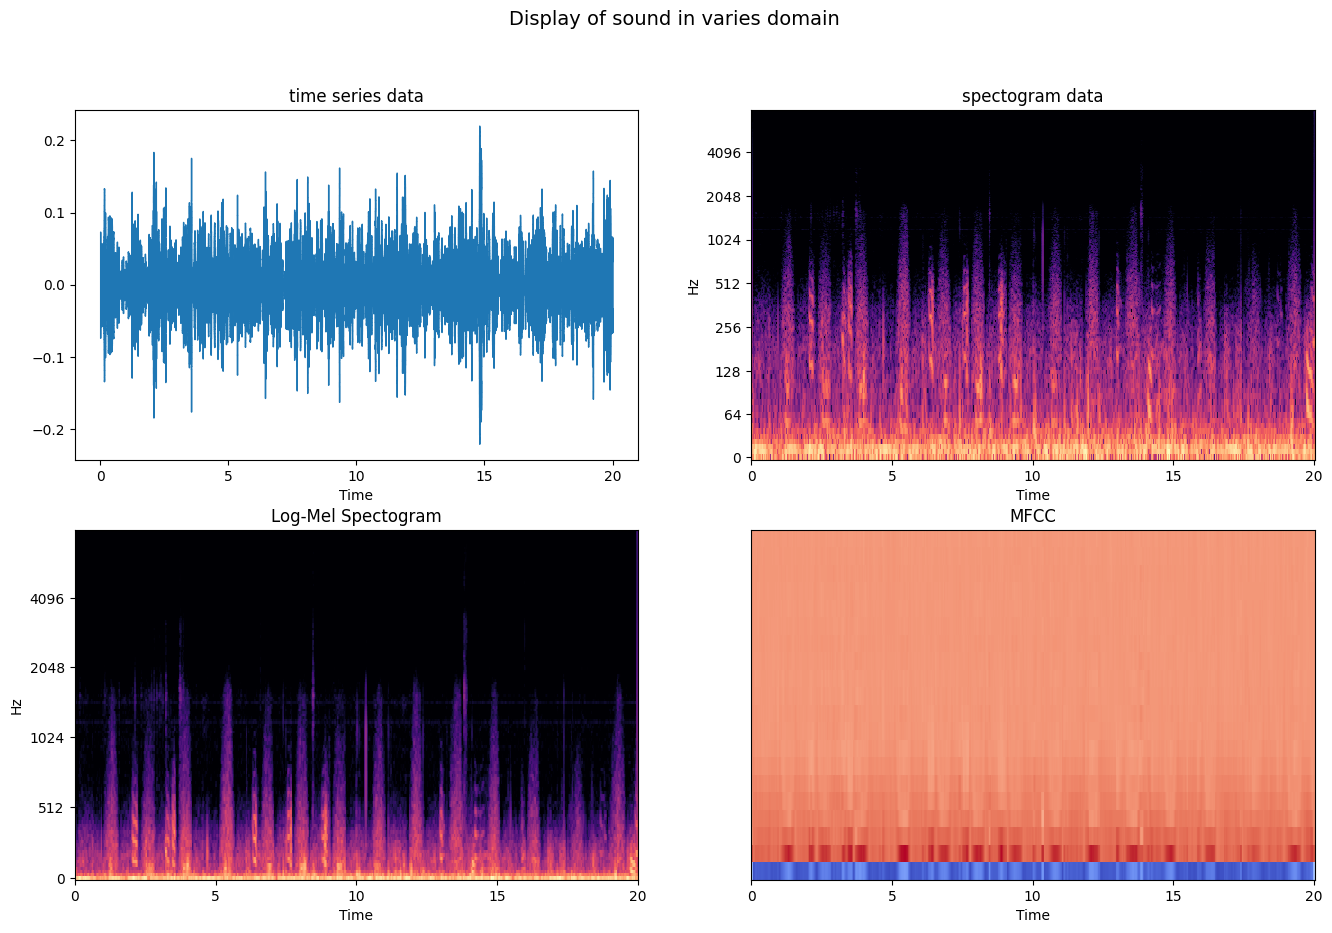

In [17]:
# Displaying sound data 
"""
  time series : amplitude of sound is varied in time domain (1D)
  spectogram : amplitude of sound is varied in time and frequency domain (2D)
"""
# time series data
sr_new = 16000 # resample 16 kHz
x, sr = librosa.load(sound_filename, sr=sr_new) # x : time series data, sr : sample rate

# Spectogram data 
X = librosa.stft(x)
Xdb = librosa.amplitude_to_db(abs(X))

# Log-mel spectogram
mel = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=128, fmax=8000)
log_mel = librosa.power_to_db(mel, ref=np.max)


# Mel-Frequency Cepstral Coefficient (MFCC)
mfccs = librosa.feature.mfcc(y=x, sr=sr)

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

librosa.display.waveshow(y=x, sr=sr, ax=ax[0, 0])
ax[0, 0].set(title='time series data')

librosa.display.specshow(Xdb, x_axis='time',
                         y_axis='log', sr=sr, ax=ax[0, 1])
ax[0, 1].set(title='spectogram data')

librosa.display.specshow(log_mel, x_axis='time',
                         y_axis='mel', sr=sr,
                         fmax=8000, ax=ax[1, 0])
ax[1, 0].set(title='Log-Mel Spectogram')


librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=ax[1, 1])
ax[1, 1].set(title='MFCC')

plt.suptitle("Display of sound in varies domain", fontsize=14);

In [22]:
mfccs.shape

(20, 626)

In [18]:
def preprocessing(audio_file, mode):
    # we want to resample audio to 16 kHz
    sr_new = 16000 # 16kHz sample rate
    x, sr = librosa.load(audio_file, sr=sr_new)

    # padding sound 
    # because duration of sound is dominantly 20 s and all of sample rate is 22050
    # we want to pad or truncated sound which is below or above 20 s respectively
    max_len = 5 * sr_new  # length of sound array = time x sample rate
    if x.shape[0] < max_len:
      # padding with zero
      pad_width = max_len - x.shape[0]
      x = np.pad(x, (0, pad_width))
    elif x.shape[0] > max_len:
      # truncated
      x = x[:max_len]
    
    if mode == 'mfcc':
      feature = librosa.feature.mfcc(y=x, sr=sr_new)
    
    elif mode == 'log_mel':
      feature = librosa.feature.melspectrogram(y=x, sr=sr_new, n_mels=128, fmax=8000)
      feature = librosa.power_to_db(feature, ref=np.max)
    

    return feature

In [ ]:
# apply preprocessing to sound data
labels = []
labels_3 = []
preprocessed_data = []
for i in tqdm(range(len(file_label_df['filename']))):
  labels.append(file_label_df['Diagnosis'][i])
  #labels_3.append(file_label_df['3 label diagnosis'][i])
  audio_file = audio_path + file_label_df['filename'][i] + '.wav'
  data = preprocessing(audio_file, mode = 'mfcc')
  preprocessed_data.append(data)
preprocessed_data = np.array(preprocessed_data) # (920, 20, 157) (num, H, W)
labels = np.array(labels) 
labels_3 = np.array(labels_3)

100%|██████████| 920/920 [01:06<00:00, 13.75it/s]


In [ ]:
preprocessed_data = preprocessed_data.reshape(-1,1,20,157)
preprocessed_data.shape # (num, C, H, W)

(920, 1, 20, 157)

In [31]:
labels_dict = {
    "COPD": 0,
    "Pneumonia": 1,
    "Healthy": 2,
    "URTI": 3,
    "Bronchiectasis": 4,
    "Bronchiolitis": 5,
    "LRTI": 6,
    "Asthma": 7
    }
labels_categorical = [labels_dict[l] for l in labels]

In [36]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(preprocessed_data, labels_categorical, test_size=0.2, random_state=42)
print("size of training set= ",len(x_train))
print("size of testing set= ",len(x_test))

size of training set=  736
size of testing set=  184


In [62]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader

In [ ]:
class Respiratory_Classifier(nn.Module):
    def __init__(self,):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 2)
        self.conv2 = nn.Conv2d(16, 32, 2)
        self.conv3 = nn.Conv2d(32, 64, 2)
        
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.2)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(64, 8)
        
        self.relu = nn.ReLU()

    def forward(self, x):
        x = torch.tensor(preprocessed_data[0])
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = self.relu(self.conv3(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = self.gap(x)
        x = x.squeeze()
        logits = self.fc(x)
        return logits
        

In [105]:
unique = []
for y in y_test:
    unique.append(list(labels_dict)[y])

In [106]:
np.unique(unique)

array(['Bronchiectasis', 'Bronchiolitis', 'COPD', 'Healthy', 'Pneumonia',
       'URTI'], dtype='<U14')